In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [362]:
!ls ./drive/MyDrive/data/div*.csv

./drive/MyDrive/data/divvy_daily.csv  ./drive/MyDrive/data/divvy_hourly.csv


In [363]:
df = pd.read_csv('./drive/MyDrive/data/divvy_daily.csv')
df = df[['date', 'rides']]
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


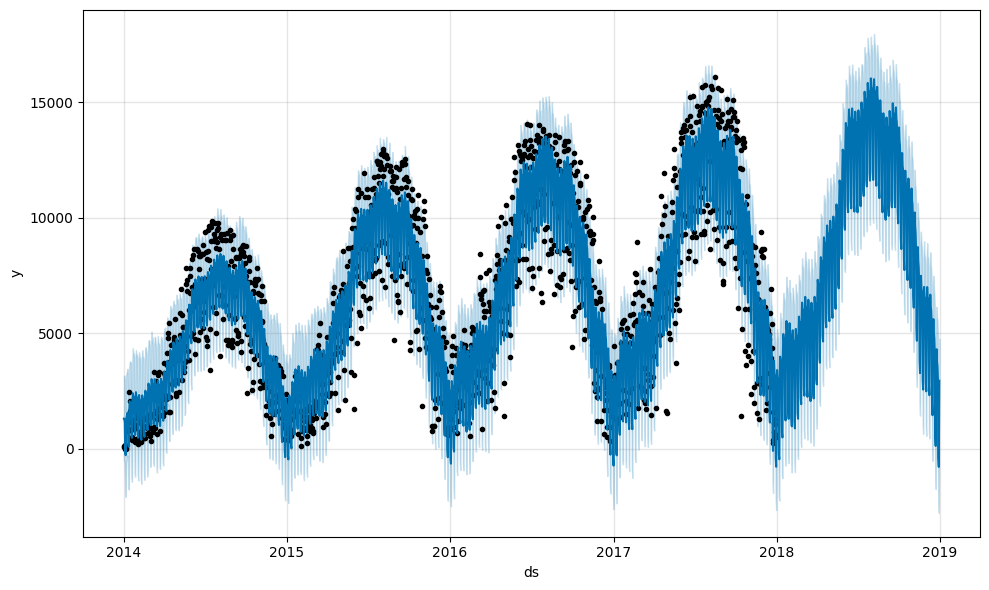

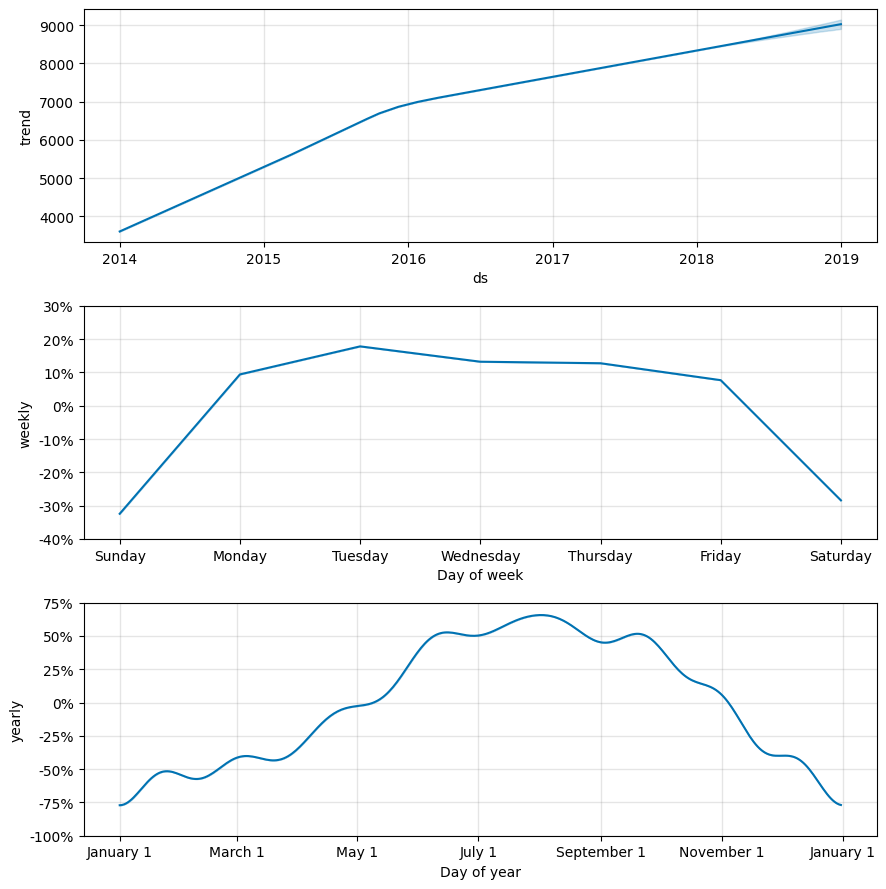

In [364]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

In [365]:
model.yearly_seasonality

'auto'

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


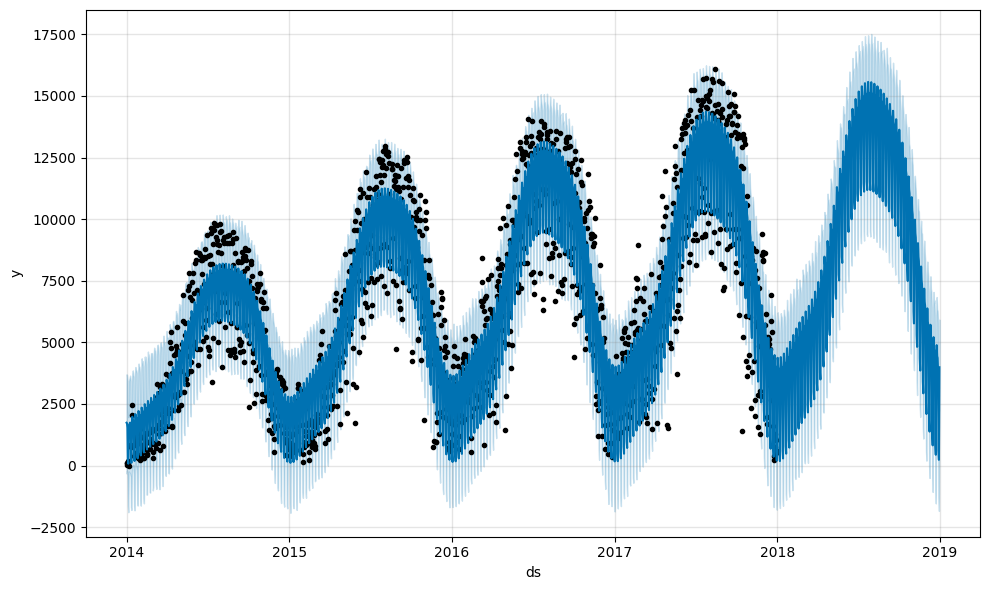

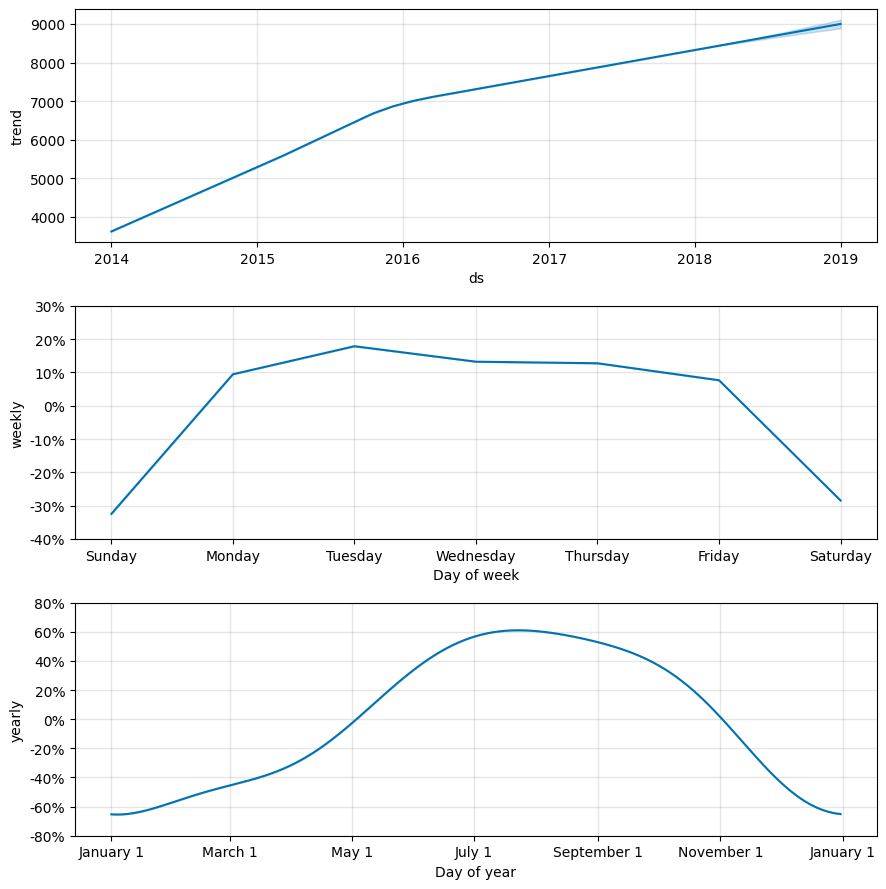

In [366]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

In [367]:
model.seasonality_prior_scale

10.0

규제 (Regularizing)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.15605e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.02913e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


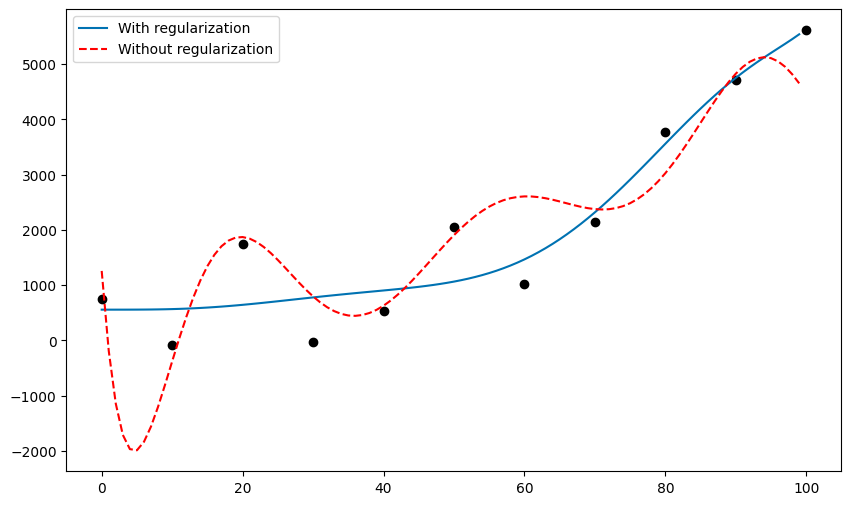

In [368]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
np.random.seed(5)
x_pure = np.arange(0, 100, 1)
y_pure = (x_pure - 20) ** 2 + 50
num_points = 12
x0 = np.arange(0, num_points * 10, 10)
y0 = ((x0 - 20) ** 2 + 50) + np.random.normal(0, 700, num_points)
polynomial_features= PolynomialFeatures(degree=8)
x_poly = polynomial_features.fit_transform(x_pure.reshape(-1, 1))
x0_poly = polynomial_features.fit_transform(x0.reshape(-1, 1))
y1 = Ridge(alpha=0).fit(x0_poly, y0).predict(x_poly)
y2 = Ridge(alpha=1000).fit(x0_poly, y0).predict(x_poly)
y3 = Ridge(alpha=1000000000).fit(x0_poly, y0).predict(x_poly)
plt.figure(figsize=(10, 6))
plt.scatter(x0[:-1], y0[:-1], c='k')
plt.plot(x_pure, y3, label='With regularization', ls='-', c='#0072B2')
plt.plot(x_pure, y1, label='Without regularization', ls='--', c='r')
plt.legend()
plt.show()

기본 : RSS 최소화

규제 : RSS + $\alpha$(회귀계수제곱의 합) 의 양을 최소화, 이때의 회귀식을 Ridge라 한다.

L2_norm을 사용하여 규제한 회귀식을 Ridge 라 한다.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


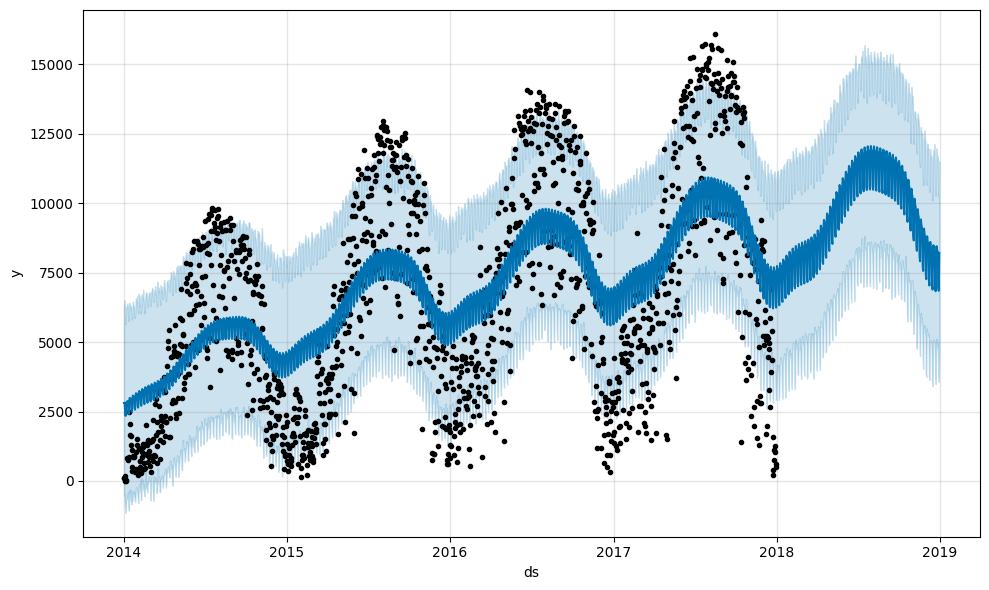

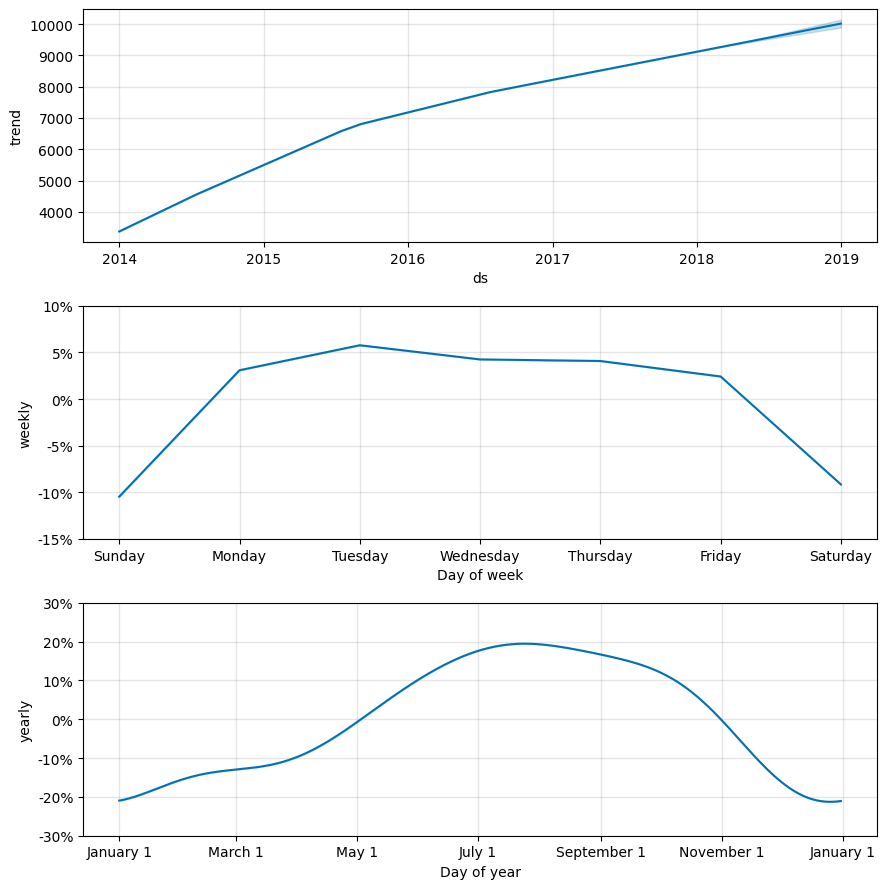

In [369]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4, seasonality_prior_scale=0.01)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

In [370]:
params = {
    'growth': model.growth,
    'changepoint_prior_scale': model.changepoint_prior_scale,
    'seasonality_prior_scale': model.seasonality_prior_scale,
    'holidays_prior_scale': model.holidays_prior_scale,
    'seasonality_mode': model.seasonality_mode,
    'yearly_seasonality': model.yearly_seasonality,
    'weekly_seasonality': model.weekly_seasonality,
    'daily_seasonality': model.daily_seasonality,
    'n_changepoints': model.n_changepoints,
}
pd.Series(params)

,0
growth,linear
changepoint_prior_scale,0.05
seasonality_prior_scale,0.01
holidays_prior_scale,10.0
seasonality_mode,multiplicative
yearly_seasonality,4
weekly_seasonality,auto
daily_seasonality,auto
n_changepoints,25


# Local seasonality regularization

연간 계절성이 기본값으로 충분, 주간 계절성이 극단적인 과적합을 보일 때.

In [371]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                weekly_seasonality=False)

In [372]:
model.add_seasonality(name = 'weekly', period=7, fourier_order=4, prior_scale=0.01)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


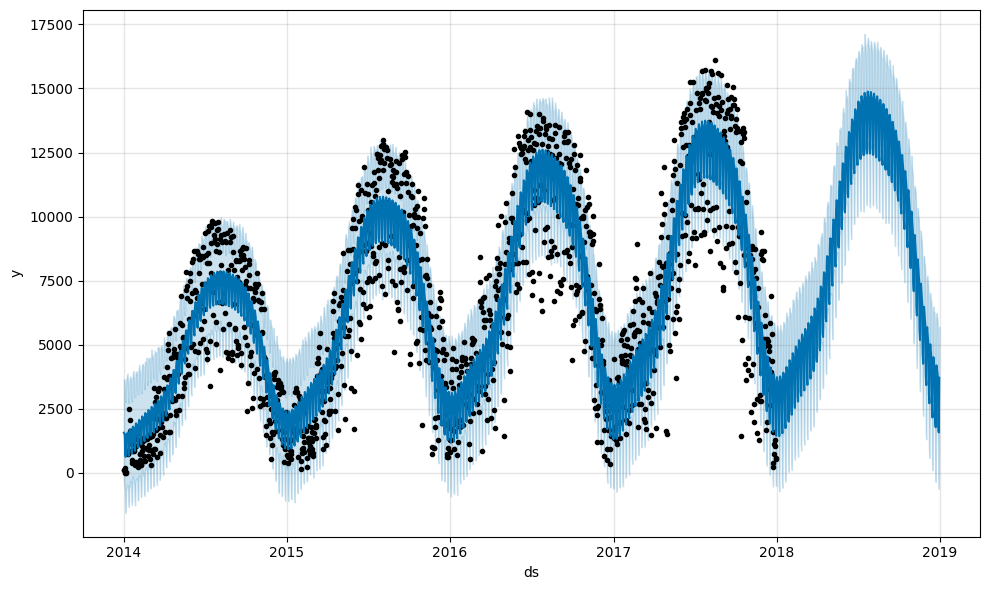

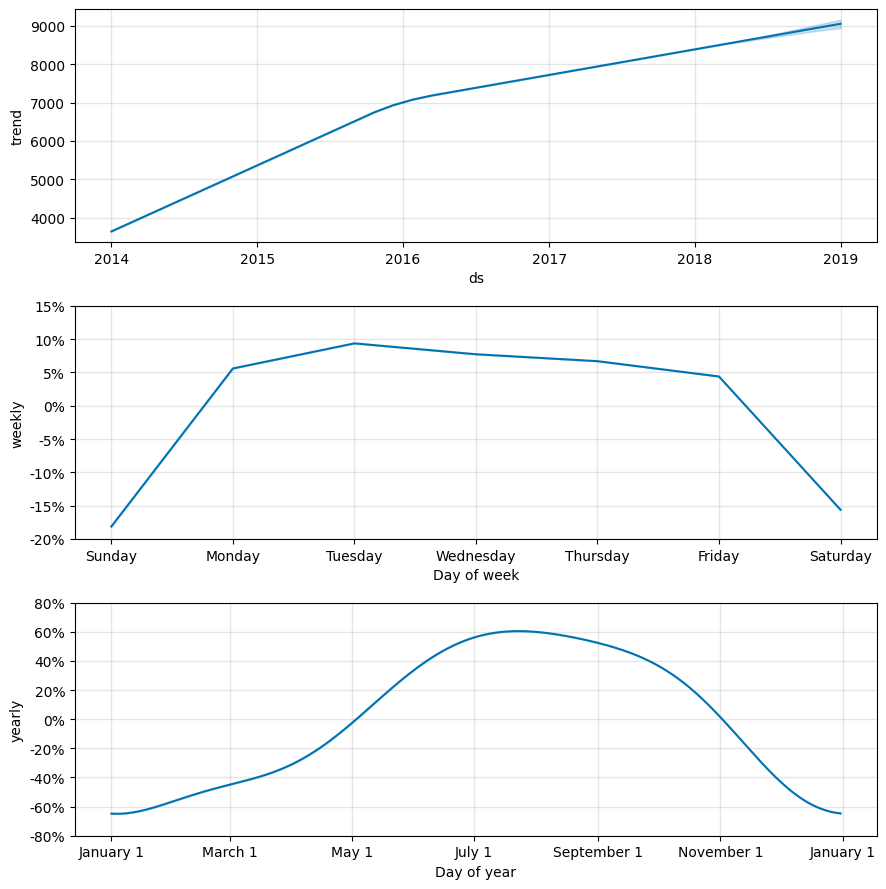

In [373]:
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

model: 규제 없음

In [374]:
model3 = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                seasonality_prior_scale=0.01)

model3.fit(df)
future3 = model3.make_future_dataframe(periods=365)
forecast3 = model3.predict(future3)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [375]:
model4 = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                seasonality_prior_scale=0.005)

model4.fit(df)
future4 = model4.make_future_dataframe(periods=365)
forecast4 = model4.predict(future4)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [376]:
from prophet.plot import seasonality_plot_df, set_y_as_percent
from matplotlib.dates import (
    MonthLocator,
    num2date,
    AutoDateLocator,
    AutoDateFormatter,
)
from matplotlib.ticker import FuncFormatter

In [377]:
def plot_seasonality2(m, name, ax=None, uncertainty=True, figsize=(10, 6), ls='-', c='#0072B2', label=''):
    artists = []
    if not ax:
        fig = plt.figure(facecolor='w', figsize=figsize)
        ax = fig.add_subplot(111)
    # Compute seasonality from Jan 1 through a single period.
    start = pd.to_datetime('2017-01-01 0000')
    period = m.seasonalities[name]['period']
    end = start + pd.Timedelta(days=period)
    plot_points = 200
    days = pd.to_datetime(np.linspace(start.value, end.value, plot_points))
    df_y = seasonality_plot_df(m, days)
    seas = m.predict_seasonal_components(df_y)
    artists += ax.plot(df_y['ds'].dt.to_pydatetime(), seas[name], ls=ls,
                        c=c, label=label)
    if uncertainty and m.uncertainty_samples:
        artists += [ax.fill_between(
            df_y['ds'].dt.to_pydatetime(), seas[name + '_lower'],
            seas[name + '_upper'], color='#0072B2', alpha=0.2)]

    ax.grid(True, which='major', c='gray', ls='-', lw=1, alpha=0.2)
    n_ticks = 8
    xticks = pd.to_datetime(np.linspace(start.value, end.value, n_ticks)
        ).to_pydatetime()
    ax.set_xticks(xticks)
    if period <= 2:
        fmt_str = '{dt:%T}'
    elif name == 'weekly':
        fmt_str = '{dt:%A}'
    elif period < 14:
        fmt_str = '{dt:%m}/{dt:%d} {dt:%R}'
    else:
        fmt_str = '{dt:%m}/{dt:%d}'
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda x, pos=None: fmt_str.format(dt=num2date(x))))
    ax.set_xlabel('ds')
    ax.set_ylabel(name)
    if m.seasonalities[name]['mode'] == 'multiplicative':
        ax = set_y_as_percent(ax)
    return artists

In [378]:
def compare_seasonality(seasonality, model_list, figsize=(10, 3), ls=['-', '--', '-.', ':'], c=['#0072B2', 'r', 'tab:orange', 'tab:green']):
    fig = plt.figure(facecolor='w', figsize=figsize)
    ax = fig.add_subplot(111)

    for model in range(len(model_list)):
        plot_seasonality2(model_list[model],
                          seasonality,
                          ax=ax,
                          ls=ls[model],
                          c=c[model],
                          label='Seasonality prior scale: {}'.format(model_list[model].seasonality_prior_scale))
    plt.legend()
    plt.show()

/tmp/ipykernel_915/1854714411.py:14: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  artists += ax.plot(df_y['ds'].dt.to_pydatetime(), seas[name], ls=ls,
/tmp/ipykernel_915/1854714411.py:18: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name + '_lower'],
/tmp/ipykernel_915/1854714411.py:14: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  artists += ax.plot(df_y['ds'].dt.to_p

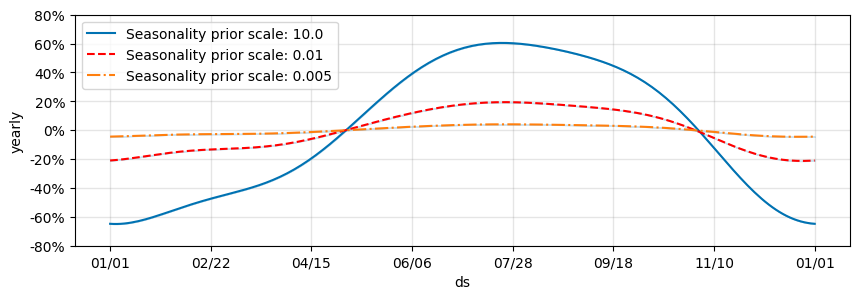

In [379]:
compare_seasonality('yearly', [model, model3, model4])

/tmp/ipykernel_915/1854714411.py:14: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  artists += ax.plot(df_y['ds'].dt.to_pydatetime(), seas[name], ls=ls,
/tmp/ipykernel_915/1854714411.py:18: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name + '_lower'],
/tmp/ipykernel_915/1854714411.py:14: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  artists += ax.plot(df_y['ds'].dt.to_p

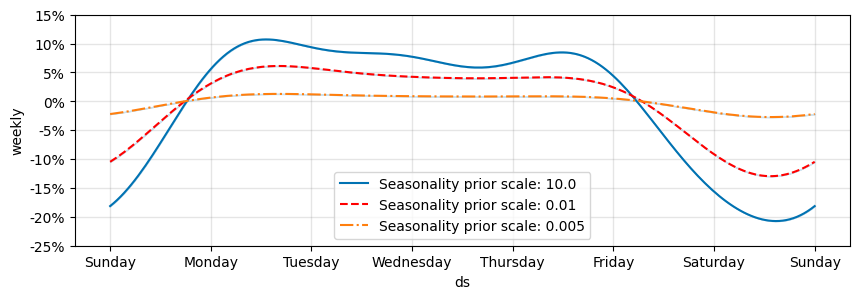

In [380]:
compare_seasonality('weekly', [model, model3, model4])

규제가 커질수록 변동 폭이 줄어든다.

푸리에 차수를 조절하여 계절성의 요동치는 회수 줄이기

규제를 가하여, 변동의 진폭을 제어

In [381]:
!ls ./drive/MyDrive/data/sun*

./drive/MyDrive/data/sunspots.csv


벨기에 왕립천문대, 1750년 부터 태양 흑점 관측, 11년 주기

In [382]:
df = pd.read_csv('./drive/MyDrive/data/sunspots.csv', usecols=['Date', 'Monthly Mean Total Sunspot Number'])

In [383]:
df

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3247,8/31/2019,0.5
3248,9/30/2019,1.1
3249,10/31/2019,0.4
3250,11/30/2019,0.5


In [384]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df.columns = ['ds', 'y']

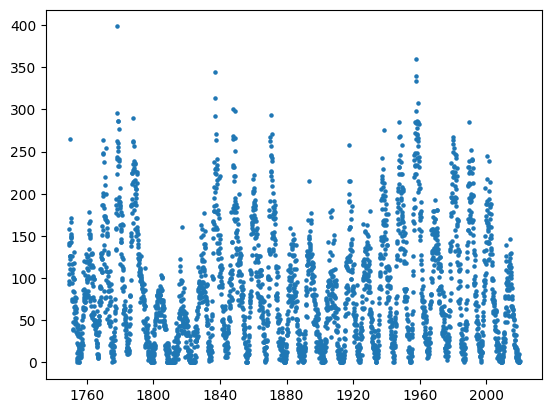

In [385]:
plt.scatter(df['ds'], df['y'], s=5)

In [386]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=False)

시간별 주기 : period = 1/24

분기별 주기 : 365.25 / 4

In [387]:
model.add_seasonality(name='11-year cycle', period=11*365.25, fourier_order=5)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


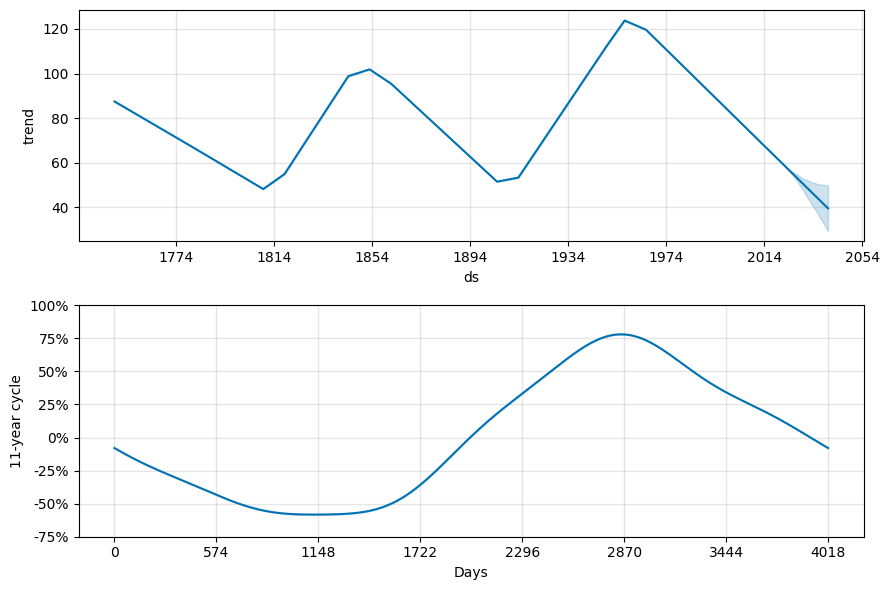

In [388]:
model.fit(df)
future = model.make_future_dataframe(periods=240, freq='M')
forecast = model.predict(future)
fig = model.plot_components(forecast)
plt.show()

In [389]:
4018/365.25

11.000684462696784

In [390]:
model.seasonalities

OrderedDict([('11-year cycle',
              {'period': 4017.75,
               'fourier_order': 5,
               'prior_scale': 10.0,
               'mode': 'multiplicative',
               'condition_name': None})])

# 조건부 계절성 적용

condition_name

- None: 모든 경유에 적용

- 값이 있으면: 특정 조건일때만 계절성 적용
예 영업일에만 weekly, seasonality 적용

In [391]:
!ls ./drive/MyDrive/data/divvy_h*

./drive/MyDrive/data/divvy_hourly.csv


In [392]:
df = pd.read_csv('./drive/MyDrive/data/divvy_hourly.csv')
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

주중: 08 ~ 18시 이용률이 높다.

주말: 모든 시간대에 고른 낮은 이용률
<br>
<br>
1. df에 주말인지 주중이지 표시하는 boolean 칼럼 추가

2. 미래예측 future에도 boolean 칼럼 추가

3. prophet 의 기본 일간 계절성 비활성화

4. 조건으로 사용하는 두개의 새로운 주간 계절성 추가

In [393]:
def is_weekend(ds):
    date = pd.to_datetime(ds)
    return (date.dayofweek == 5) | (date.dayofweek == 6)

In [394]:
pd.Timestamp('2026-04-26').dayofweek

6

In [395]:
df['weekend'] = df['ds'].apply(is_weekend)

In [396]:
df

,ds,y,weekend
0,2014-01-01 01:00:00,1,False
1,2014-01-01 02:00:00,9,False
2,2014-01-01 03:00:00,4,False
3,2014-01-01 04:00:00,1,False
4,2014-01-01 07:00:00,2,False
...,...,...,...
34711,2017-12-31 20:00:00,10,True
34712,2017-12-31 21:00:00,9,True
34713,2017-12-31 22:00:00,3,True
34714,2017-12-31 23:00:00,8,True


In [397]:
# 1. df에 주말인지 주중이지 표시하는 boolean 칼럼 추가
df['weekend'] = df['ds'].apply(is_weekend)
df['weekday'] = ~df['ds'].apply(is_weekend)

In [398]:
df

,ds,y,weekend,weekday
0,2014-01-01 01:00:00,1,False,True
1,2014-01-01 02:00:00,9,False,True
2,2014-01-01 03:00:00,4,False,True
3,2014-01-01 04:00:00,1,False,True
4,2014-01-01 07:00:00,2,False,True
...,...,...,...,...
34711,2017-12-31 20:00:00,10,True,False
34712,2017-12-31 21:00:00,9,True,False
34713,2017-12-31 22:00:00,3,True,False
34714,2017-12-31 23:00:00,8,True,False


In [399]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=6,
                weekly_seasonality=6,
                daily_seasonality=False) # 일간 계절성만 끔

In [400]:
model.add_seasonality(name='daily_weekend',
                      period=1,
                      fourier_order=3,
                      condition_name='weekend')
model.add_seasonality(name='daily_weekday',
                      period=1,
                      fourier_order=3,
                      condition_name='weekday')

In [401]:
model.fit(df)
future = model.make_future_dataframe(periods=365*24, freq='h')
# 2. 미래예측 future에도 boolean 칼럼 추가
future['weekend'] = future['ds'].apply(is_weekend)
future['weekday'] = ~future['ds'].apply(is_weekend)

In [402]:
forecast = model.predict(future)
from prophet.plot import plot_seasonality

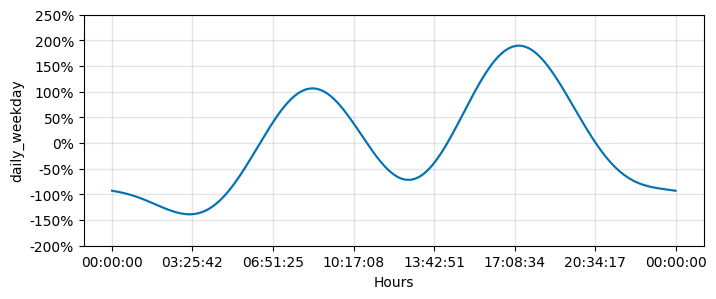

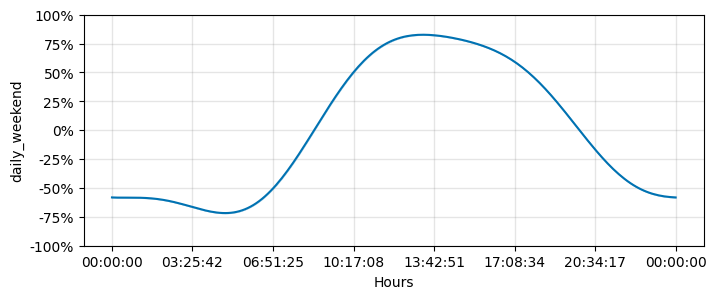

In [403]:
fig = plot_seasonality(model, 'daily_weekday', figsize=(8, 3))
plt.show()
fig = plot_seasonality(model, 'daily_weekend', figsize=(8, 3))
plt.show()

# 공휴일 효과

In [404]:
!ls ./drive/MyDrive/data/divvy_daily.csv

./drive/MyDrive/data/divvy_daily.csv


In [405]:
df = pd.read_csv('./drive/MyDrive/data/divvy_daily.csv')
df = df[['date', 'rides']]
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

In [406]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4)

In [407]:
model.add_country_holidays(country_name='US')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


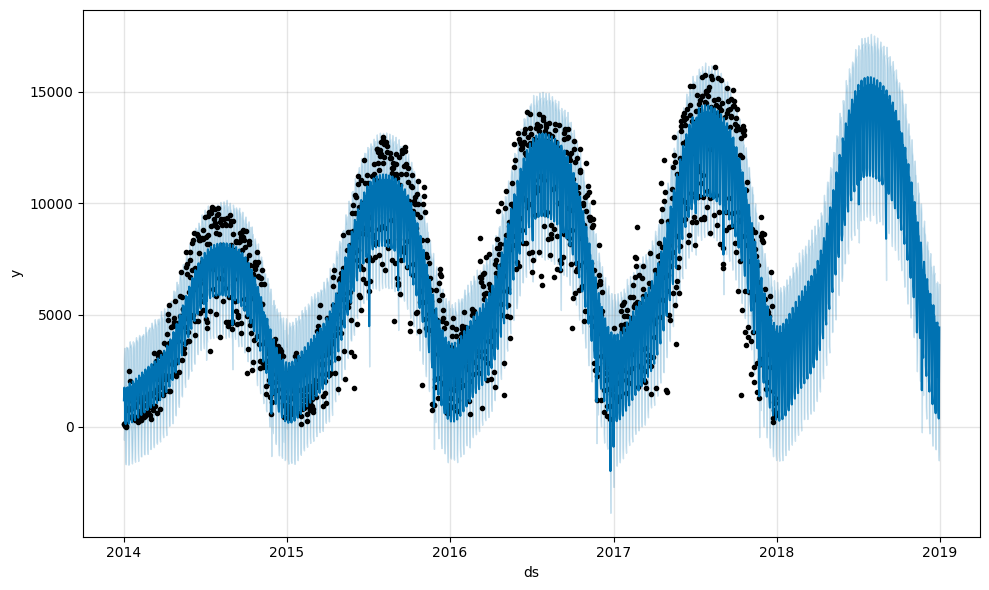

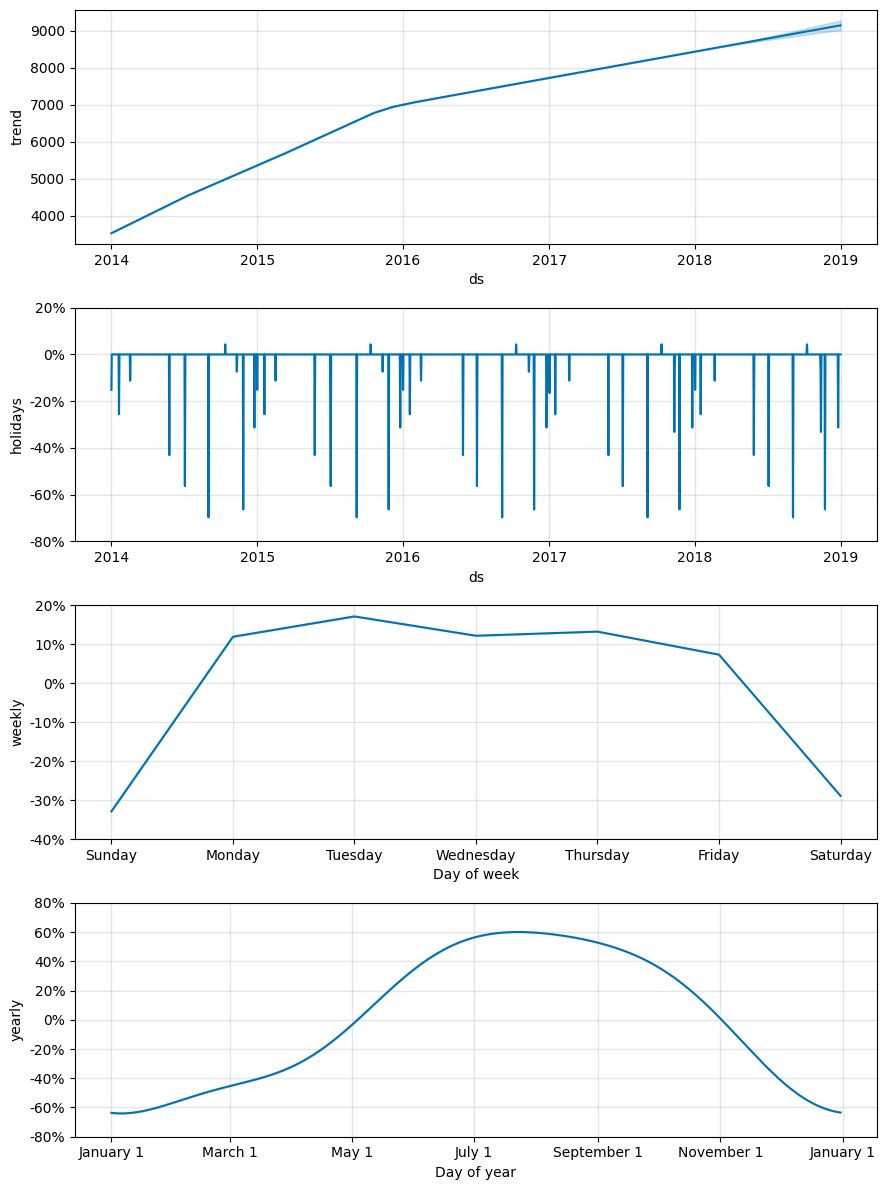

In [408]:
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

In [409]:
params

{'growth': 'linear',
 'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 0.01,
 'holidays_prior_scale': 10.0,
 'seasonality_mode': 'multiplicative',
 'yearly_seasonality': 4,
 'weekly_seasonality': 'auto',
 'daily_seasonality': 'auto',
 'n_changepoints': 25}

In [410]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4, seasonality_prior_scale=0.05)
model.add_country_holidays(country_name='US')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


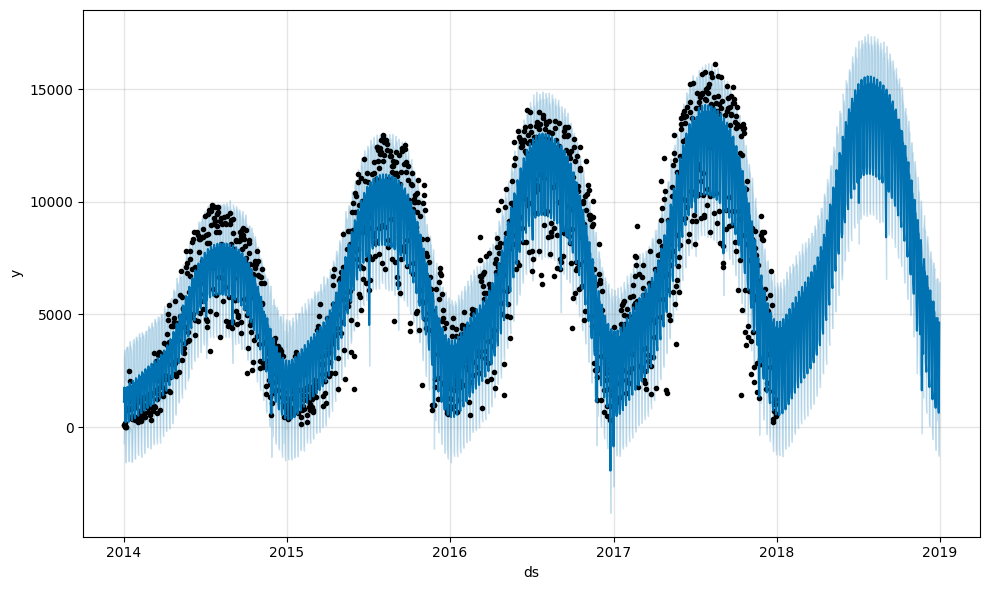

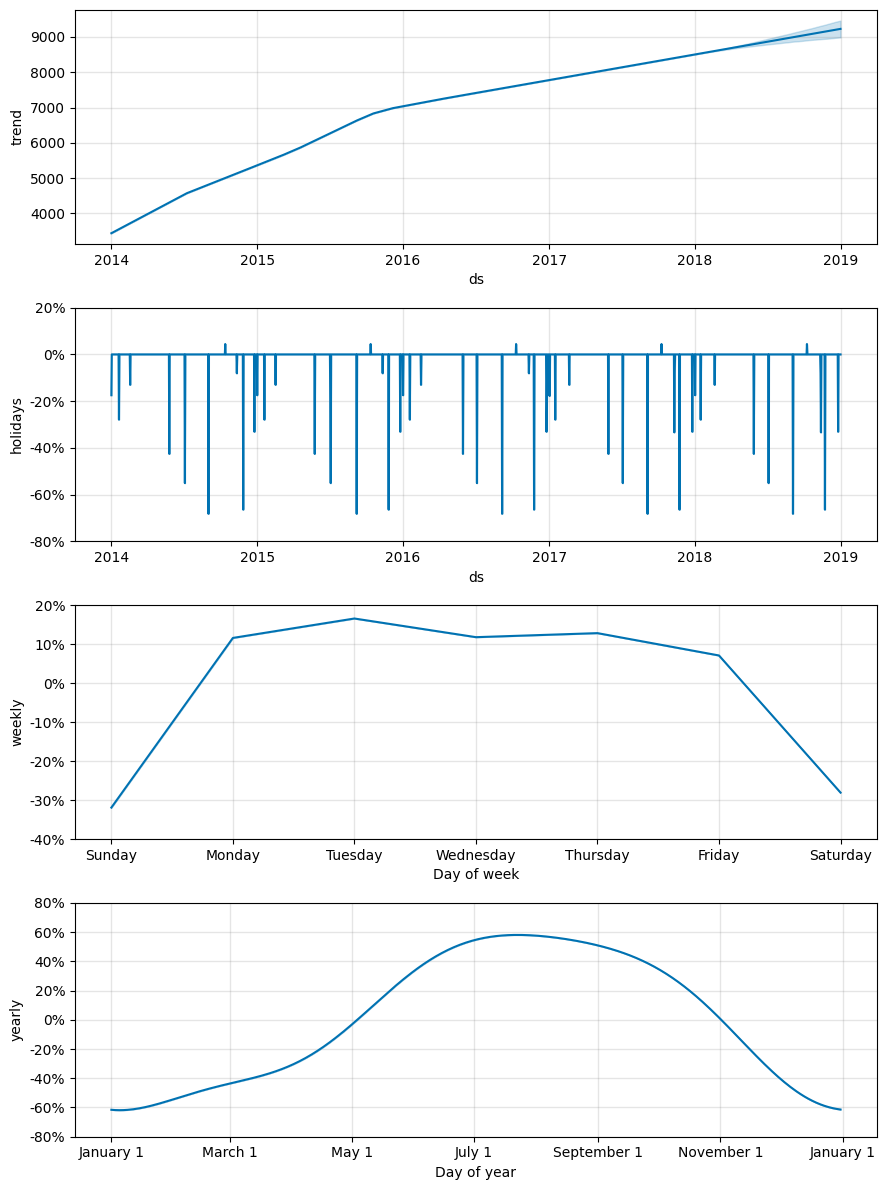

In [411]:
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()

In [412]:
model.train_holiday_names

,0
0,New Year's Day
1,Memorial Day
2,Independence Day
3,Labor Day
4,Thanksgiving Day
5,Christmas Day
6,Christmas Day (observed)
7,Martin Luther King Jr. Day
8,Washington's Birthday
9,Columbus Day


In [413]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Christmas Day', 'Christmas Day_lower', 'Christmas Day_upper',
       'Christmas Day (observed)', 'Christmas Day (observed)_lower',
       'Christmas Day (observed)_upper', 'Columbus Day', 'Columbus Day_lower',
       'Columbus Day_upper', 'Independence Day', 'Independence Day_lower',
       'Independence Day_upper', 'Independence Day (observed)',
       'Independence Day (observed)_lower',
       'Independence Day (observed)_upper', 'Labor Day', 'Labor Day_lower',
       'Labor Day_upper', 'Martin Luther King Jr. Day',
       'Martin Luther King Jr. Day_lower', 'Martin Luther King Jr. Day_upper',
       'Memorial Day', 'Memorial Day_lower', 'Memorial Day_upper',
       'New Year's Day', 'New Year's Day_lower', 'New Year's Day_upper',
       'New Year's Day (observed)', 'New Year's Day (observed)_lower',
       'New Year's Day (observed)_upper', 'Thanksgiving Day',
       'Thanksgiving Day_lower', 'T

In [414]:
forecast['Columbus Day'].value_counts()

,count
Columbus Day,
0.000000,1818
0.044364,5


In [415]:
def first_non_zero(fcst, holiday):
    return fcst[fcst[holiday] != 0][holiday].values[0]

In [416]:
pd.DataFrame({'holiday': model.train_holiday_names, 'effect':[first_non_zero(forecast, holiday) for holiday in model.train_holiday_names]})

,holiday,effect
0,New Year's Day,-0.174598
1,Memorial Day,-0.425596
2,Independence Day,-0.550498
3,Labor Day,-0.681803
4,Thanksgiving Day,-0.663969
5,Christmas Day,-0.330935
6,Christmas Day (observed),-0.216861
7,Martin Luther King Jr. Day,-0.279070
8,Washington's Birthday,-0.130331
9,Columbus Day,0.044364


In [417]:
m = Prophet().add_country_holidays(country_name='KR').fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [418]:
m.train_holiday_names

,0
0,New Year's Day
1,Korean New Year
2,The day preceding Korean New Year
3,The second day of Korean New Year
4,Independence Movement Day
5,Buddha's Birthday
6,Children's Day
7,Memorial Day
8,Liberation Day
9,National Foundation Day


In [419]:
import holidays
from datetime import date

In [420]:
kr_holidays = holidays.KR(years=2025)

In [421]:
kr_holidays.items()

dict_items([(datetime.date(2025, 1, 1), "New Year's Day"), (datetime.date(2025, 1, 29), 'Korean New Year'), (datetime.date(2025, 1, 28), 'The day preceding Korean New Year'), (datetime.date(2025, 1, 30), 'The second day of Korean New Year'), (datetime.date(2025, 3, 1), 'Independence Movement Day'), (datetime.date(2025, 5, 5), "Buddha's Birthday; Children's Day"), (datetime.date(2025, 6, 6), 'Memorial Day'), (datetime.date(2025, 8, 15), 'Liberation Day'), (datetime.date(2025, 10, 3), 'National Foundation Day'), (datetime.date(2025, 10, 9), 'Hangul Day'), (datetime.date(2025, 10, 6), 'Chuseok'), (datetime.date(2025, 10, 5), 'The day preceding Chuseok'), (datetime.date(2025, 10, 7), 'The second day of Chuseok'), (datetime.date(2025, 12, 25), 'Christmas Day'), (datetime.date(2025, 3, 3), 'Alternative holiday for Independence Movement Day'), (datetime.date(2025, 5, 6), "Alternative holiday for Buddha's Birthday; Alternative holiday for Children's Day"), (datetime.date(2025, 10, 8), 'Alterna

# 검증, 지표

In [422]:
!ls ./drive/MyDrive/data/onlin*

./drive/MyDrive/data/online_retail.csv


In [423]:
df = pd.read_csv('./drive/MyDrive/data/online_retail.csv')
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

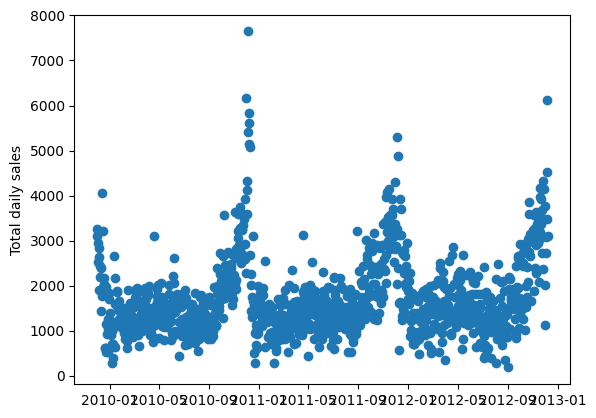

In [424]:
plt.scatter(df['ds'], df['y'])
plt.ylabel('Total daily sales')
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


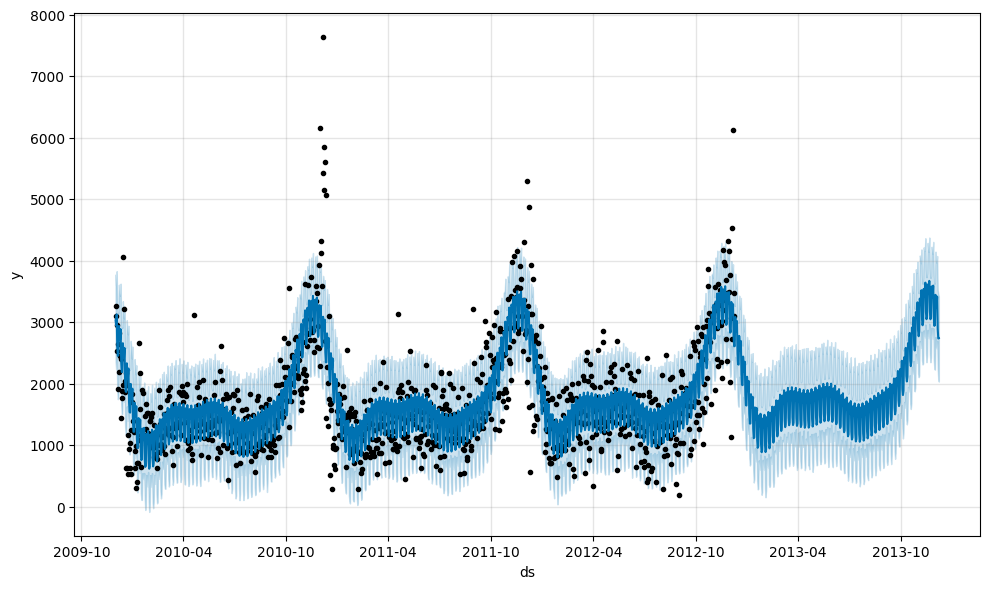

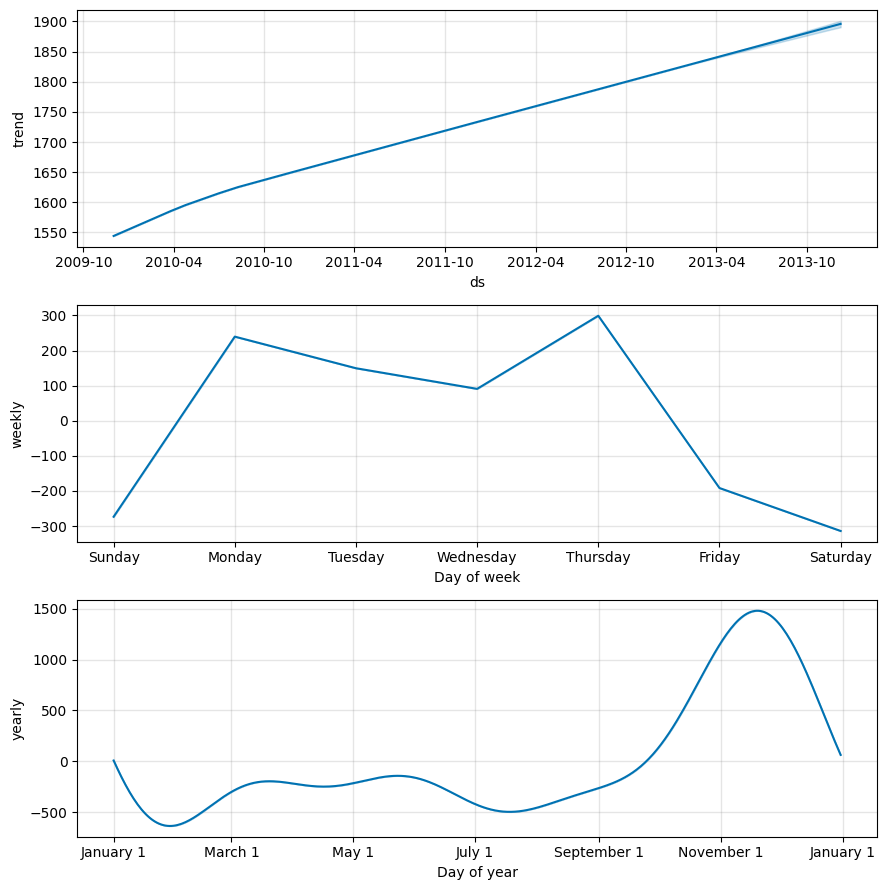

In [425]:
model = Prophet(yearly_seasonality=4)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
print('\n')
plt.show()

In [426]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

In [427]:
df_cv = cross_validation(model, horizon='90 days', period='30 days', initial='730 days', parallel='processes')

INFO:prophet:Making 10 forecasts with cutoffs between 2011-12-14 00:00:00 and 2012-09-09 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7c57bf20b3e0>


In [428]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2011-12-15,2801.202360,2070.099496,3474.331201,3702.986147,2011-12-14
1,2011-12-16,2352.319098,1671.015785,3033.852306,1229.263629,2011-12-14
2,2011-12-17,2182.374126,1459.509504,2919.476129,1325.415023,2011-12-14
3,2011-12-18,2165.463230,1448.480262,2899.453187,2739.454215,2011-12-14
4,2011-12-19,2636.148978,1891.666026,3374.930973,2699.823386,2011-12-14
...,...,...,...,...,...,...
895,2012-12-04,3107.791500,2469.034744,3802.199122,2726.403434,2012-09-09
896,2012-12-05,3022.979755,2373.555691,3695.056109,4528.532962,2012-09-09
897,2012-12-06,3173.204390,2516.503642,3867.829719,6125.495419,2012-09-09
898,2012-12-07,2672.853949,2035.591921,3359.046194,3476.642731,2012-09-09


In [429]:
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,221665.142875,470.813278,379.417900,0.300611,0.232033,0.258407,0.855556
1,10 days,218207.518250,467.126876,375.159615,0.297620,0.222063,0.255952,0.866667
2,11 days,202994.669649,450.549298,368.446968,0.287860,0.201322,0.251089,0.888889
3,12 days,179271.973616,423.405212,350.791003,0.273825,0.207288,0.240962,0.933333
4,13 days,173224.058556,416.201944,344.674210,0.261011,0.189870,0.234347,0.944444
...,...,...,...,...,...,...,...,...
77,86 days,268636.564985,518.301616,417.236096,0.401589,0.196844,0.268277,0.788889
78,87 days,296040.903595,544.096410,439.624151,0.426687,0.203495,0.285007,0.766667
79,88 days,367045.299948,605.842636,442.651723,0.386394,0.201823,0.268820,0.777778
80,89 days,373196.277012,610.897927,452.390639,0.376433,0.203495,0.266074,0.755556


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


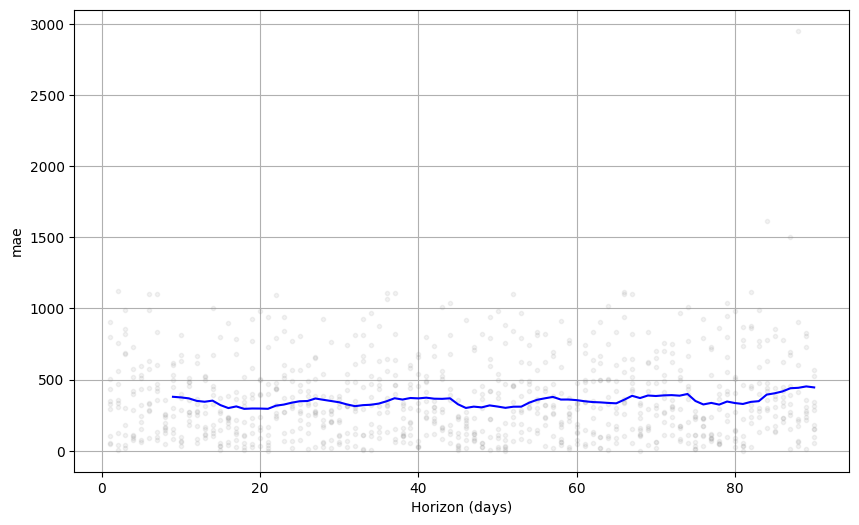

In [430]:
fig = plot_cross_validation_metric(df_cv, metric='mae')
plt.show()

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be remov

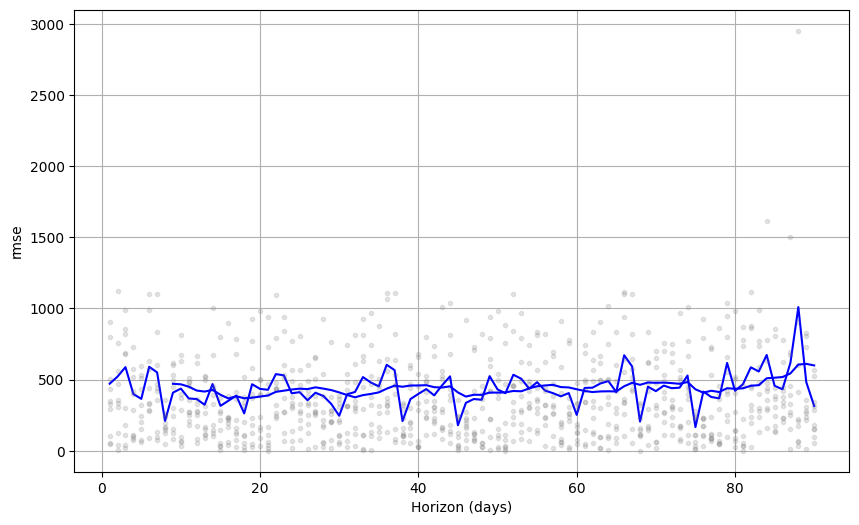

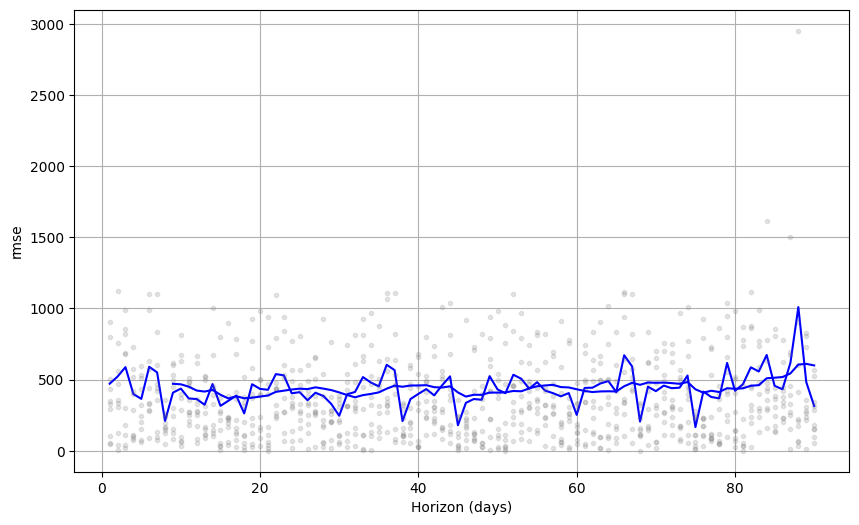

In [431]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
plot_cross_validation_metric(df_cv, metric='rmse', rolling_window=.01, ax=ax)
plot_cross_validation_metric(df_cv, metric='rmse', rolling_window=.1, ax=ax)

In [432]:
df_pref = performance_metrics(df_cv, rolling_window=1)

In [433]:
df_pref

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,90 days,206056.834942,453.934836,356.077728,0.308406,0.185392,0.239573,0.864444


1. 주식 데이터 불러오기

2. Close 사용

3. 30일 예측, 2년치 데이터 가져오기

4. streamlit에 표출 (colab도 가능)

In [434]:
!pip install yfinance

In [435]:
import yfinance as yf
import datetime

In [465]:
code = '086790.KS'

In [466]:
start = datetime.datetime(2024, 4, 1)
end = datetime.datetime(2026, 4, 1)

In [467]:
df = yf.download(code, start, end)

/tmp/ipykernel_915/328843078.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(code, start, end)
[*********************100%***********************]  1 of 1 completed


In [468]:
df

Price,Close,High,Low,Open,Volume
Ticker,086790.KS,086790.KS,086790.KS,086790.KS,086790.KS
Date,,,,,
2024-04-01,51318.523438,52774.368074,50954.562278,52228.426335,912736
2024-04-02,51409.515625,51864.467091,50226.641814,50499.612694,1515193
2024-04-03,50590.605469,51773.479338,50499.615171,51500.508445,1330468
2024-04-04,53047.339844,53684.271883,50863.572852,50954.563143,1473327
2024-04-05,52592.386719,53684.270180,51409.512969,51955.454700,902301
...,...,...,...,...,...
2026-03-25,108700.000000,110700.000000,108000.000000,109800.000000,977916
2026-03-26,108800.000000,110500.000000,108000.000000,109700.000000,884501


In [469]:
df = df[['Close']].reset_index()

In [470]:
df.columns

MultiIndex([( 'Date',          ''),
            ('Close', '086790.KS')],
           names=['Price', 'Ticker'])

In [471]:
df.columns = ['ds', 'y']

In [472]:
df

,ds,y
0,2024-04-01,51318.523438
1,2024-04-02,51409.515625
2,2024-04-03,50590.605469
3,2024-04-04,53047.339844
4,2024-04-05,52592.386719
...,...,...
478,2026-03-25,108700.000000
479,2026-03-26,108800.000000
480,2026-03-27,110400.000000
481,2026-03-30,107200.000000


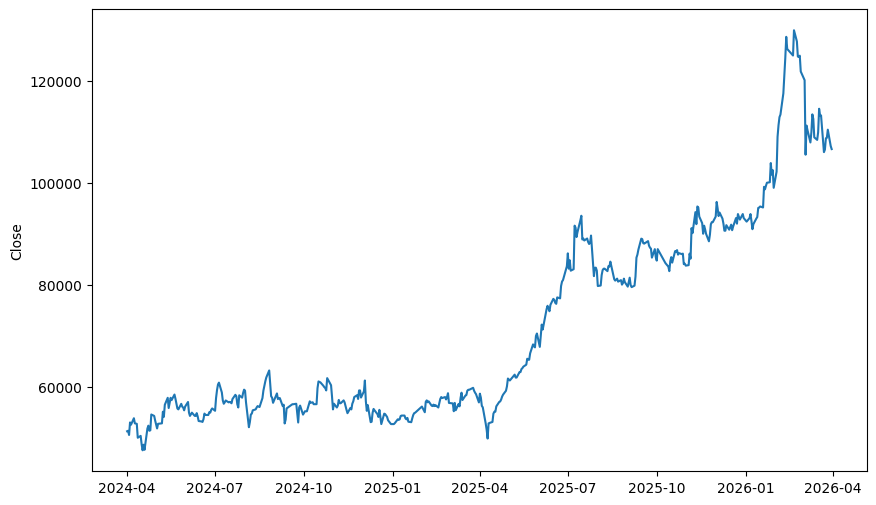

In [482]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['ds'], df['y'])
ax.set_ylabel('Close')
plt.show()

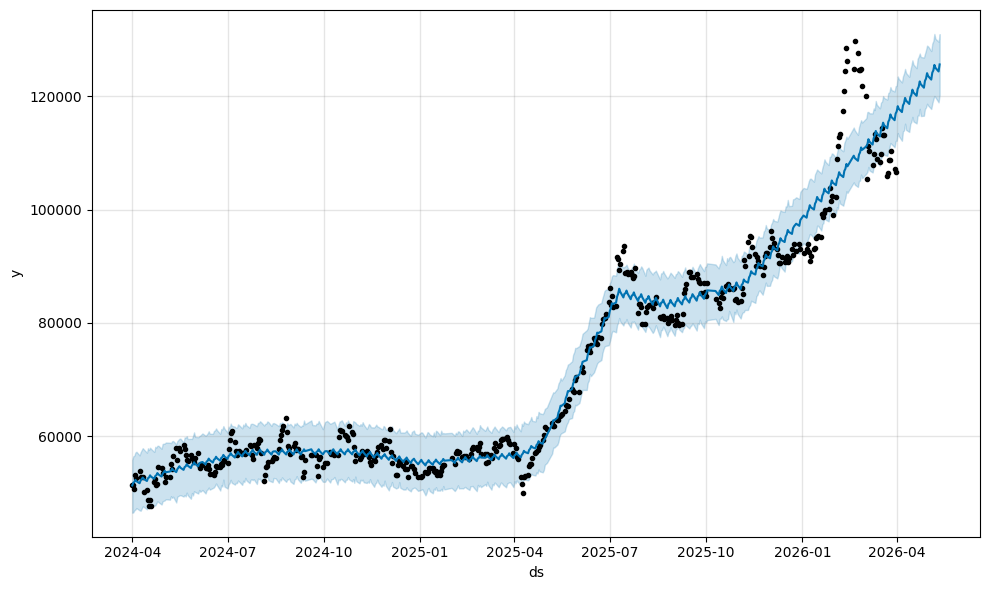

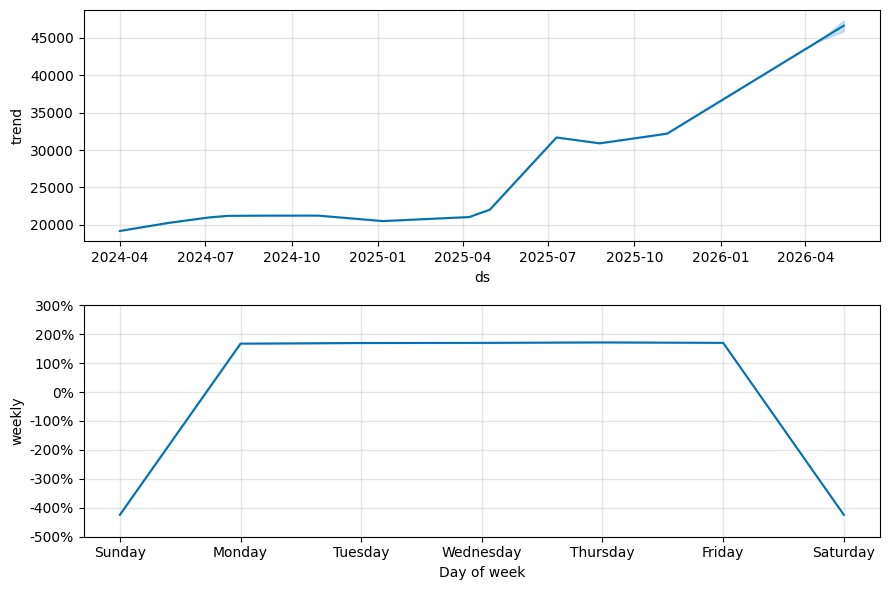

In [479]:
model = Prophet(seasonality_mode='multiplicative', weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
model.fit(df)
future = model.make_future_dataframe(periods=30, freq='B')
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig = model.plot_components(forecast)
plt.show()